### Weather data EDA

Conducted a comprehensive Exploratory Data Analysis (EDA) on a weather dataset using Python, Pandas, Matplotlib, and Seaborn to identify data quality issues, understand variable distributions, and uncover relationships between weather conditions and environmental factors.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv(r"C:\Users\haree\OneDrive\Desktop\HARESSH_work\python_vs_code\my_project\wether\weather_data.csv",index_col=0)

Data Cleaning & Preparation

In [4]:
data.head()

,Ozone,Solar.R,Wind,Temp C,Month,Day,Year,Temp,Weather
1,41.0,190.0,7.4,67,5,1,2025,67,S
2,36.0,118.0,8.0,72,5,2,2025,72,C
3,12.0,149.0,12.6,74,5,3,2025,74,PS
4,18.0,313.0,11.5,62,5,4,2025,62,S
5,NaN,NaN,14.3,56,5,5,2025,56,S


In [5]:
data.tail()

,Ozone,Solar.R,Wind,Temp C,Month,Day,Year,Temp,Weather
155,30.0,193.0,6.9,70,9,26,2025,70,PS
156,NaN,145.0,13.2,77,9,27,2025,77,S
157,14.0,191.0,14.3,75,9,28,2025,75,S
158,18.0,131.0,8.0,76,9,29,2025,76,C
158,18.0,131.0,8.0,76,9,29,2025,76,C


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 161 entries, 1 to 158
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    123 non-null    float64
 1   Solar.R  154 non-null    float64
 2   Wind     161 non-null    float64
 3   Temp C   161 non-null    object 
 4   Month    161 non-null    object 
 5   Day      161 non-null    int64  
 6   Year     161 non-null    int64  
 7   Temp     161 non-null    int64  
 8   Weather  158 non-null    object 
dtypes: float64(3), int64(3), object(3)
memory usage: 12.6+ KB


In [7]:
data.dtypes

Ozone      float64
Solar.R    float64
Wind       float64
Temp C      object
Month       object
Day          int64
Year         int64
Temp         int64
Weather     object
dtype: object

In [8]:
data.isnull().sum()

Ozone      38
Solar.R     7
Wind        0
Temp C      0
Month       0
Day         0
Year        0
Temp        0
Weather     3
dtype: int64

In [9]:
data.columns

Index(['Ozone', 'Solar.R', 'Wind', 'Temp C', 'Month', 'Day', 'Year', 'Temp',
       'Weather'],
      dtype='object')

In [10]:
data.duplicated().sum()

np.int64(4)

In [11]:
data.drop_duplicates(inplace=True)

In [12]:
data.duplicated().sum()

np.int64(0)

In [14]:
data['Ozone']=data['Ozone'].fillna(data['Ozone'].mean())

In [15]:
data.drop(columns=['Temp C'],inplace=True)

In [16]:
data.rename({"Solar.R":"Solar"},axis=1,inplace=True)

In [17]:
data['Month'].unique()

array(['5', 'May', '6', '7', '8', '9'], dtype=object)

In [18]:
data['Month']=data['Month'].replace({'May':5})

In [19]:
data['Month'].unique()

array(['5', 5, '6', '7', '8', '9'], dtype=object)

In [20]:
data['Date']=pd.to_datetime(data[['Year','Month','Day']])

*   Loaded and inspected the dataset structure, data types, and missing values.
*   Removed duplicate records to improve data quality.
*   Imputed missing values in the Ozone column using mean imputation.
*   Dropped redundant columns and standardized column names for better readability.
*   Converted Year, Month, and Day columns into a single Date column for time-series analysis.
*   Performed basic data transformation and validation checks.

#### Outliers

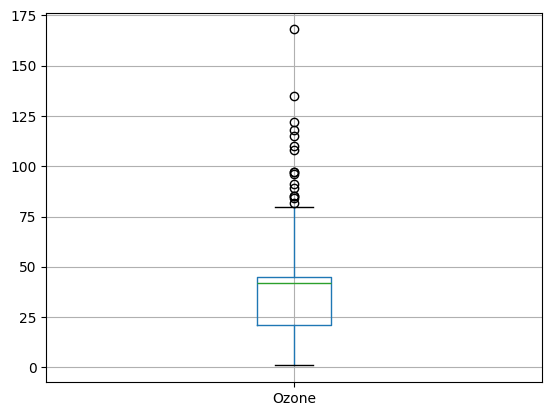

In [21]:
data.boxplot(column='Ozone')
plt.show()

Performed outlier detection on Ozone concentration levels using box plots to identify extreme values and assess data distribution for further analysis and preprocessing.

#### Categorical columns

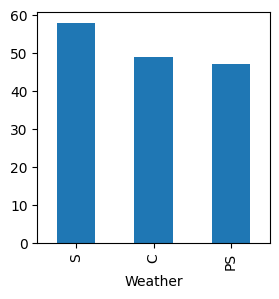

In [22]:
plt.figure(figsize=(3,3))
data['Weather'].value_counts().plot(kind='bar')
plt.show()

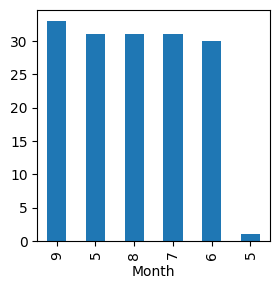

In [23]:
plt.figure(figsize=(3,3))
data['Month'].value_counts().plot(kind='bar')
plt.show()

* Evaluated the distribution of different weather conditions using bar charts to identify dominant weather patterns.
* Analyzed monthly observation frequencies to understand seasonal trends and data distribution across time periods.

#### Numerical columns

In [24]:
data.var(numeric_only=True)

Ozone     806.807261
Solar    7924.408277
Wind       12.286342
Day        80.539931
Year        0.000000
Temp       88.460314
dtype: float64

In [25]:
data.skew(numeric_only=True)

Ozone    1.456531
Solar   -0.414117
Wind     0.365064
Day     -0.026555
Year     0.000000
Temp    -0.344782
dtype: float64

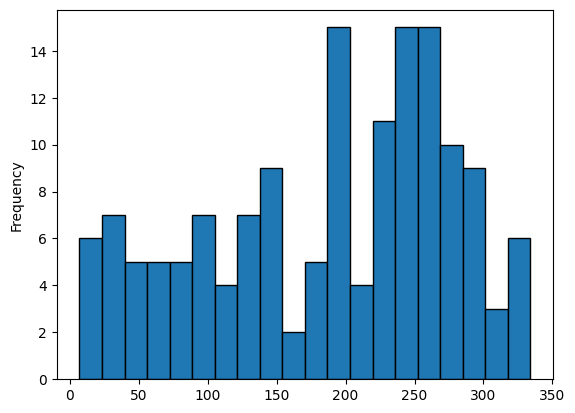

In [26]:
data['Solar'].plot(kind='hist',bins=20,edgecolor='black')
plt.show()

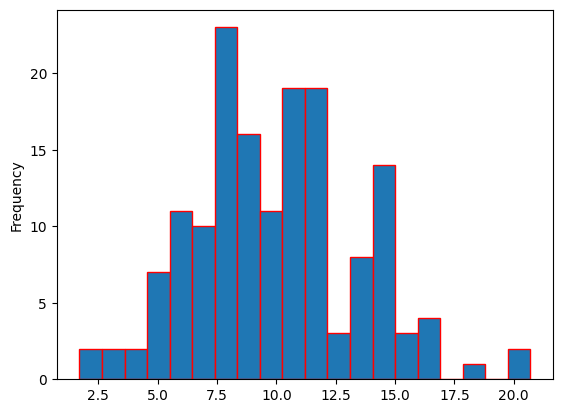

In [27]:
data['Wind'].plot(kind='hist',bins=20,edgecolor='red')
plt.show()

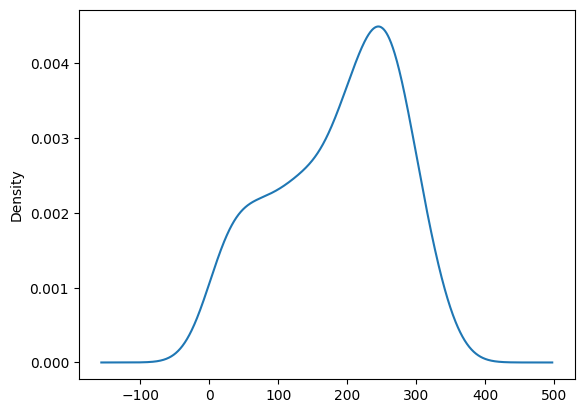

In [28]:
data['Solar'].plot(kind='kde')
plt.show()

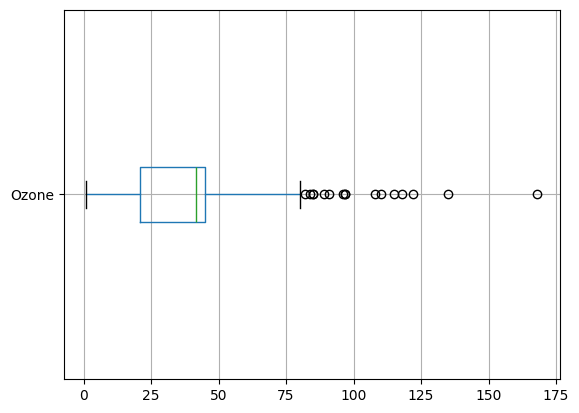

In [29]:
data.boxplot(column='Ozone',vert=False)
plt.show()

* Calculated variance and skewness to evaluate variability and distribution characteristics of numerical weather variables.
* Analyzed the distribution of Solar Radiation and Wind Speed using histograms and Kernel Density Estimation (KDE) plots.
* Identified and assessed outliers in Ozone levels through box plot visualizations to understand data anomalies and variability.

##### distribution plot

<Figure size 300x300 with 0 Axes>

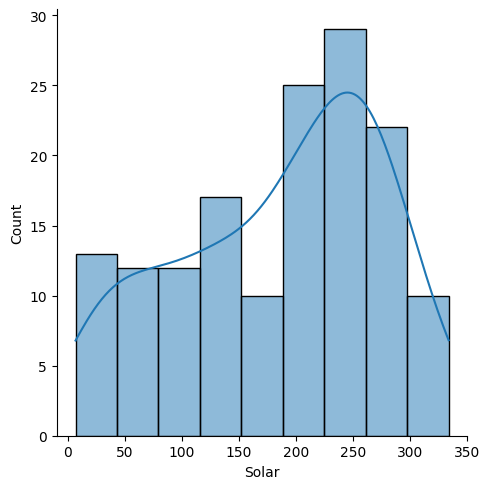

In [30]:
plt.figure(figsize=(3,3))
sns.displot(x='Solar',data=data,kind='hist',kde=True)
plt.show()

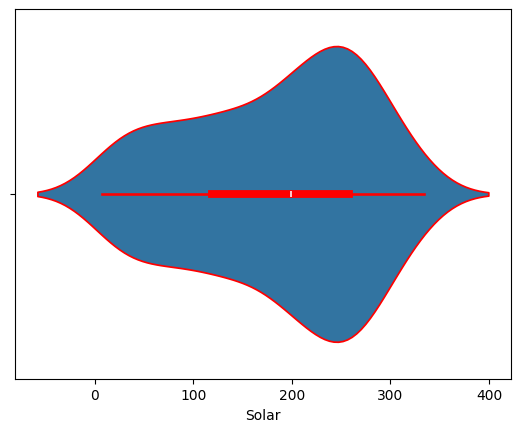

In [31]:
sns.violinplot(x='Solar',data=data,edgecolor='red')
plt.show()

* Visualized Solar Radiation distribution using histogram and KDE plots to assess data distribution patterns and density.
* Used violin plots to examine the spread, distribution shape, and variability of Solar Radiation values.

### Bivariate & Multivariate Analysis (feature relationships)


Numerical vs Numerical
* Scater plot, Correlation matrix (heatmap),Pairplots

Categorical Vs Numerical
*   Box plot, Bar plots, violin plots


Categoricla vs Numerical
*   cross tabs

Date vs Nemerical

Grouped statistics with group by

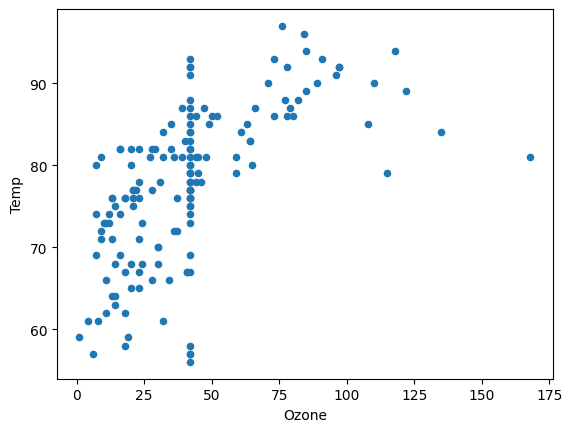

In [32]:
data.plot(kind='scatter',x='Ozone',y='Temp')
plt.show()

Performed correlation analysis between Ozone concentration and Temperature using scatter plots to identify trends, relationships, and potential dependencies between environmental variables.

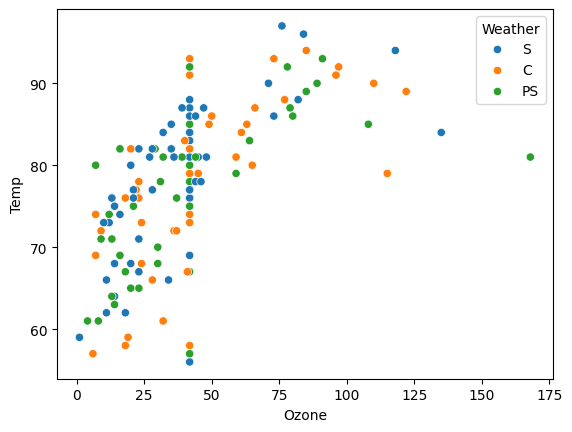

In [33]:
sns.scatterplot(x='Ozone',y='Temp',data=data,hue='Weather')
plt.show()

Explored interactions between Ozone concentration, Temperature, and Weather conditions to identify trends and correlations affecting air quality.

In [34]:
df=data.drop('Year',axis=1)

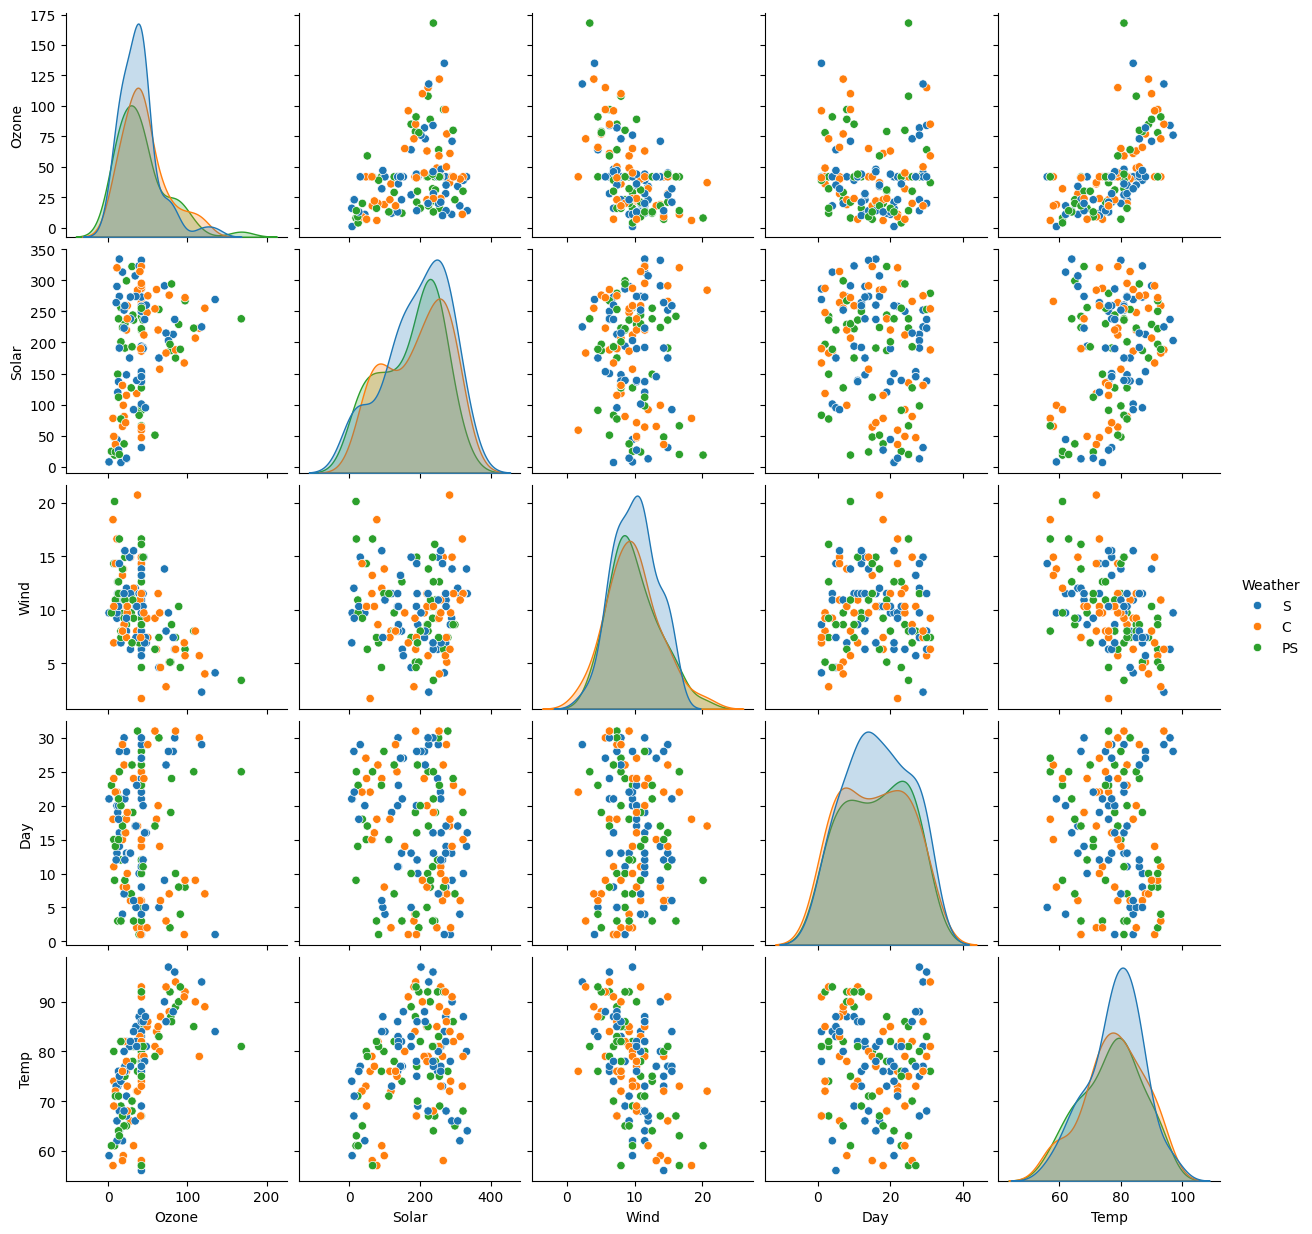

In [35]:
sns.pairplot(data=df,hue='Weather')
# works for only numerical data
plt.show()

Conducted multivariate analysis using pair plots to visualize relationships among numerical weather variables and identify patterns across different weather conditions.

In [36]:
df.corr(numeric_only=True)

,Ozone,Solar,Wind,Day,Temp
Ozone,1.000000,0.308687,-0.520004,-0.021916,0.606500
Solar,0.308687,1.000000,-0.057407,-0.155663,0.273558
Wind,-0.520004,-0.057407,1.000000,0.029900,-0.441228
Day,-0.021916,-0.155663,0.029900,1.000000,-0.122787
Temp,0.606500,0.273558,-0.441228,-0.122787,1.000000


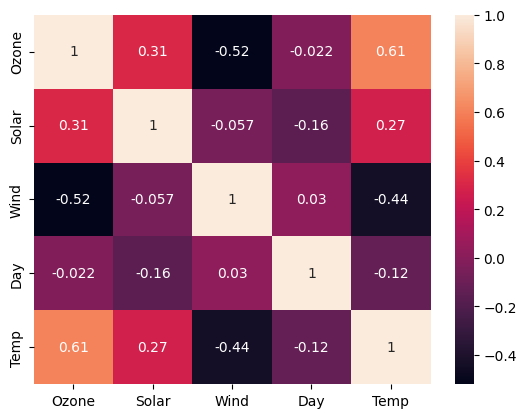

In [37]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

Generated a correlation heatmap to identify the strength and direction of relationships among weather variables, helping uncover key factors influencing Ozone levels.

#### Categorical Vs Numerical

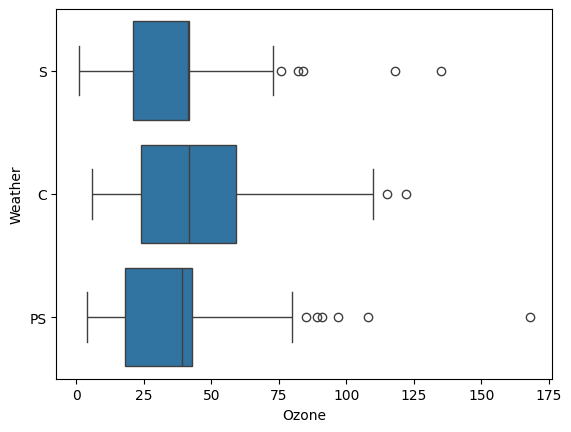

In [38]:
sns.boxplot(x='Ozone',y='Weather',data=data)
plt.show()

Compared Ozone concentration across different weather conditions using box plots to identify variations, spread, and outlier patterns within each weather category.

Date vs Numerical 

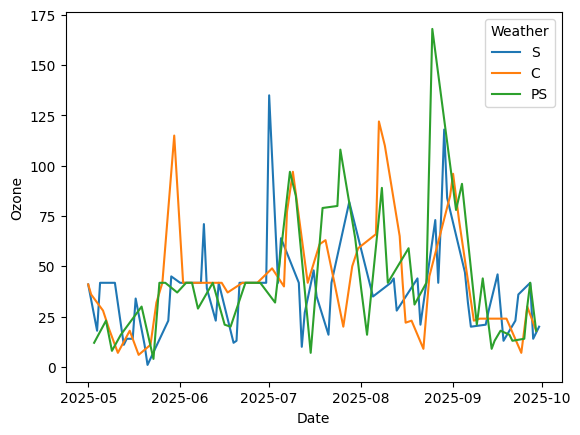

In [39]:
sns.lineplot(x='Date',y='Ozone',data=data,hue='Weather')
plt.show()

Conducted time-series analysis of Ozone levels using line plots to identify temporal trends and compare air quality patterns across different weather conditions.

In [40]:
pd.crosstab(data['Month'],data['Weather'])

Weather,C,PS,S
Month,,,
5,1,0,0
5,10,9,12
6,9,9,12
7,11,8,11
8,10,8,11
9,8,13,12


Grouping Statistics

In [41]:
data.groupby('Weather').mean(numeric_only=True)

,Ozone,Solar,Wind,Day,Year,Temp
Weather,,,,,,
C,45.097582,192.391304,9.783673,15.489796,2025.0,77.734694
PS,42.105668,174.347826,9.908511,16.042553,2025.0,76.872340
S,38.572877,193.375000,10.020690,16.465517,2025.0,78.120690


In [42]:
# what are the average values of numerical features when the weather is sunny

data[data['Weather']=='S'].mean(numeric_only=True)

Ozone      38.572877
Solar     193.375000
Wind       10.020690
Day        16.465517
Year     2025.000000
Temp       78.120690
dtype: float64

In [43]:
# what is the average temperature during the month june whe the weather is cloudy
data[(data['Month']=='6') & (data['Weather']=='C')]['Temp'].mean()

np.float64(78.33333333333333)

In [44]:
# what is maximum of wind speed wduring july when weather is sunny?
data[(data['Month']=='7') & (data['Weather']=='S')]['Wind'].max()

np.float64(14.9)

I performed a complete Exploratory Data Analysis (EDA) on weather data to assess data quality, understand variable distributions, identify outliers, analyze relationships between atmospheric factors such as ozone, temperature, solar radiation, and wind speed, evaluate weather patterns across months, and uncover trends over time using statistical analysis and data visualization techniques in Python using Pandas, Matplotlib, and Seaborn.